In [1]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics, plot_mask_distributions

In [2]:
def compute_rowwise_metrics(row, just_f1=True):
    g = np.array(row['g_test'])        # shape (n, p)
    pred = np.array(row['binary_mask'])
    
    # True Positives, False Positives, False Negatives per row
    TP = np.sum((pred == 1) & (g == 1), axis=1)
    FP = np.sum((pred == 1) & (g == 0), axis=1)
    FN = np.sum((pred == 0) & (g == 1), axis=1)
    
    # Compute metrics per row
    TPR = TP / (TP + FN + 1e-10)
    FDR = FP / (TP + FP + 1e-10)
    F1  = 2 * TP / (2 * TP + FP + FN + 1e-10)
    
    # Take mean across all rows in this experiment
    if just_f1 == True:
        return pd.Series({
                'F1' : np.mean(F1)
            })
    else:
        return pd.Series({
                'TPR': np.mean(TPR),
                'FDR': np.mean(FDR),
                'F1' : np.mean(F1)
            })

## Set up

tuning with the set labelled 'test'. And the evaluating with the set labelled 'val'.

In [16]:
switch = load_results_from_pickle(folder='ICML_experiments/semi_syn_cred/tuning_lambda',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False#'bigtestuse_marginal_True'
                                        )#'after_hadi_conversation3')# #"%y_%m_%d_%H_%M_%S"
temp = switch.copy()
temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)
temp['model'] = temp['model_type']
temp['seed'] = temp['seed'].astype(int)
temp['syn'] = temp['syn'].str[-1].astype(int)

In [17]:
temp = temp.query('syn != 7')

In [18]:
runs = temp.T.loc['run_id'].value_counts().index

# SemiSyn

## Determining lambda for each model

Tuned across [0.01, 0.05, 0.1 , 0.2 , 0.3 , 0.4 ].

In [8]:
numeric_cols = ['lmbda','accuracy', 'syn', 'roc_auc', 'TPR_mean', 'FDR_mean', 'f1', 'pct_sig']
for col in numeric_cols:
    temp[col] = temp[col].astype(float)

Note, this is across Syn1-6

In [10]:
cols = ['model','lmbda','accuracy', 'roc_auc', 'pct_sig']
temp.query('syn>3')[cols].groupby(['model','lmbda']).mean()

accuracy   roc_auc   pct_sig
model         lmbda                              
hide_and_seek 0.01   0.730889  0.797448  0.996614
              0.05   0.738000  0.804560  0.563411
              0.10   0.738222  0.810102  0.305058
              0.20   0.735111  0.806670  0.176053
              0.30   0.734556  0.802786  0.141507
              0.40   0.733889  0.799613  0.127444
realx         0.01   0.727111  0.792874  0.641029
              0.05   0.716333  0.780436  0.190179
              0.10   0.717667  0.775125  0.135314
              0.20   0.712000  0.768178  0.083420
              0.30   0.702667  0.751808  0.057932
              0.40   0.692667  0.744809  0.057227

In [9]:
temp[['model','lmbda']].value_counts()

model      lmbda
Hide&Seek  0.01     6
           0.05     6
           0.10     6
           0.20     6
           0.30     6
           0.40     6
realx      0.01     6
           0.05     6
           0.10     6
           0.20     6
           0.30     6
           0.40     6
Name: count, dtype: int64

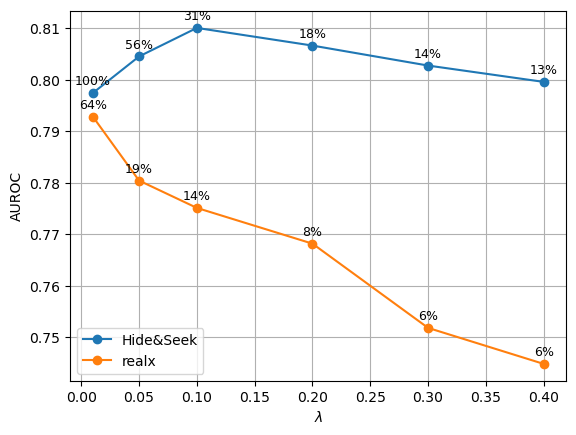

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

df = temp.query('syn>3')[cols].groupby(['model','lmbda']).mean()

for model, g in df.reset_index()[['model','lmbda','roc_auc','pct_sig']].groupby('model'):
    g = g.sort_values('lmbda')
    ax.plot(g['lmbda'], g['roc_auc'], marker='o', label=model)

    # annotate each point
    for _, row in g.iterrows():
        ax.annotate(
            f"{row['pct_sig']*100:.0f}%",
            (row['lmbda'], row['roc_auc']),
            textcoords="offset points",
            xytext=(0, 6),
            ha='center',
            fontsize=9
        )

ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('AUROC')
ax.legend()
ax.grid(True)
plt.show()


In [23]:
assert 1==2

AssertionError: 

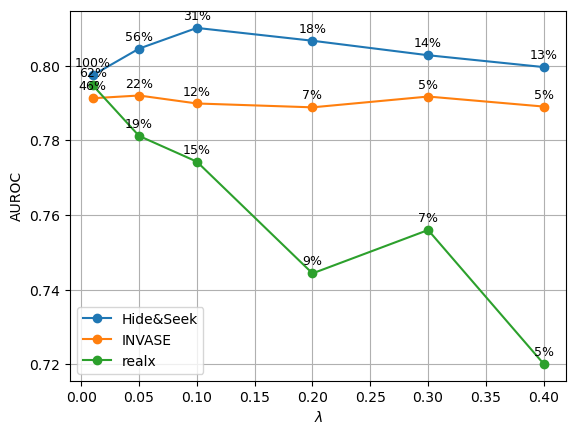

In [262]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

df = temp.query('syn>3')[cols].groupby(['model','lmbda']).mean()

for model, g in df.reset_index()[['model','lmbda','roc_auc','pct_sig']].groupby('model'):
    g = g.sort_values('lmbda')
    ax.plot(g['lmbda'], g['roc_auc'], marker='o', label=model)

    # annotate each point
    for _, row in g.iterrows():
        ax.annotate(
            f"{row['pct_sig']*100:.0f}%",
            (row['lmbda'], row['roc_auc']),
            textcoords="offset points",
            xytext=(0, 6),
            ha='center',
            fontsize=9
        )

ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('AUROC')
ax.legend()
ax.grid(True)
plt.show()


Pick the lambda which has a high roc_auc for a low pct_sig. Before roc_auc drops off. Aim to have a similar pct_sig for comparison.

- Hide&Seek: 0.1, 30%
- RealX: 0.05, 19% (did not do 0.01 60% - FDR just super high, tagging everything)
- INVASE: 0.05, 22%

In [263]:
cols = ['syn','model','lmbda','accuracy', 'roc_auc', 'TPR_mean', 'FDR_mean', 'f1','pct_sig']
temp.query('syn>3')[cols].groupby(['model','lmbda']).mean().drop('syn',axis=1)

accuracy   roc_auc    TPR_mean   FDR_mean         f1  \
model     lmbda                                                         
Hide&Seek 0.01   0.730889  0.797448  100.000000  81.363080  31.197517   
          0.05   0.738000  0.804560   97.742222  62.730406  52.048774   
          0.10   0.738222  0.810102   93.488148  43.041969  69.912986   
          0.20   0.735111  0.806670   72.939259  23.640339  73.127380   
          0.30   0.734556  0.802786   63.775555  18.962703  68.985926   
          0.40   0.733889  0.799613   58.598518  18.608514  65.436202   
INVASE    0.01   0.726556  0.791274   92.954815  59.217866  54.554948   
          0.05   0.724444  0.792003   71.653333  31.629668  67.051190   
          0.10   0.725111  0.789868   49.874074  18.776518  58.582808   
          0.20   0.724889  0.788835   34.830370   6.679708  47.309046   
          0.30   0.725778  0.791725   22.728148   3.303441  33.307515   
          0.40   0.724333  0.789043   21.515556   4.548601  31.625776   
realx     0.01   0.729222  0.794723   85.375555  74.076343  38.775326   
          0.05   0.714556  0.781177   60.515555  38.632738  57.255724   
          0.10   0.713222  0.774281   61.492592  27.511737  64.081796   
          0.20   0.707333  0.744365   40.416296  15.372394  51.198483   
          0.30   0.684889  0.755983   30.476296   8.705873  43.261843   
          0.40   0.700778  0.720122   24.477037   6.457910  34.693017   

                  pct_sig  
model     lmbda            
Hide&Seek 0.01   0.996614  
          0.05   0.563411  
          0.10   0.305058  
          0.20   0.176053  
          0.30   0.141507  
          0.40   0.127444  
INVASE    0.01   0.462275  
          0.05   0.220391  
          0.10   0.115473  
          0.20   0.074865  
          0.30   0.046367  
          0.40   0.045087  
realx     0.01   0.619676  
          0.05   0.190077  
          0.10   0.153454  
          0.20   0.092860  
          0.30   0.066135  
          0.40   0.054643

Note - when looking at Syn2, INVASE has better results than hide&seek, realx - could be worth investigating

## Results - TPR, FDR

In [20]:
results = load_results_from_pickle(folder='ICML_experiments/semi_syn_cred/after_tuning_lambda',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False#'bigtestuse_marginal_True'
                                        )#'after_hadi_conversation3')# #"%y_%m_%d_%H_%M_%S"

In [21]:
results.model.value_counts()

REAL-x           120
INVASE           120
Hide&Seek        120
Hide&Seek_ens    120
Name: model, dtype: int64

In [22]:
temp=results.copy()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)
temp['model'] = temp['model_type']
temp['seed'] = temp['seed'].astype(int)
temp['syn'] = temp['syn'].str[-1].astype(int)
temp['pct_sig'] = temp['binary_mask'].apply(lambda x: x.mean(axis=1).mean())
temp = temp.query('syn != 7')

In [152]:
# temp = temp[~((temp['model']=='Hide&Seek') & (temp['lmbda']==0.1))]
# temp = temp[~((temp['model']=='realx') & (temp['lmbda']==0.01))]
# temp = temp[~((temp['model']=='realx') & (temp['lmbda']==0.1))]

In [23]:
numeric_cols = ['lmbda','accuracy', 'syn', 'roc_auc', 'TPR_mean', 'FDR_mean', 'f1', 'pct_sig']
for col in numeric_cols:
    temp[col] = temp[col].astype(float)

In [24]:
runs = temp.T.loc['run_id'].value_counts().index

In [25]:
# temp = temp.query('syn>3')

In [26]:
temp[['model','syn','lmbda']].value_counts()

model              syn  lmbda
hide_and_seek      1.0  0.10     20
                   2.0  0.10     20
                   3.0  0.10     20
                   4.0  0.10     20
                   5.0  0.10     20
                   6.0  0.10     20
hide_and_seek_ens  1.0  0.10     20
                   2.0  0.10     20
                   3.0  0.10     20
                   4.0  0.10     20
                   5.0  0.10     20
                   6.0  0.10     20
invase             1.0  0.05     20
                   2.0  0.05     20
                   3.0  0.05     20
                   4.0  0.05     20
                   5.0  0.05     20
                   6.0  0.05     20
realx              1.0  0.05     20
                   2.0  0.05     20
                   3.0  0.05     20
                   4.0  0.05     20
                   5.0  0.05     20
                   6.0  0.05     20
dtype: int64

In [27]:
cols = ['model','lmbda','syn','accuracy', 'roc_auc', 'TPR_mean', 'FDR_mean', 'f1', 'pct_sig']
independent_medians = temp[cols].groupby(['model','lmbda','syn']).median()
# independent_medians = independent_medians.reset_index()
independent_medians

accuracy   roc_auc    TPR_mean   FDR_mean  \
model             lmbda syn                                              
hide_and_seek     0.10  1.0  0.611167  0.664297   99.866666   1.250622   
                        2.0  0.932667  0.885553   66.579167  25.852758   
                        3.0  0.694667  0.765951   99.620833   0.004167   
                        4.0  0.737000  0.829347   86.607778  34.066910   
                        5.0  0.635667  0.702033   96.400000  27.628926   
                        6.0  0.820833  0.865975   86.840000  38.796253   
hide_and_seek_ens 0.10  1.0  0.613167  0.666902   99.983333   0.244444   
                        2.0  0.935500  0.897373   64.295833   7.975559   
                        3.0  0.696000  0.768518   99.875000   0.000000   
                        4.0  0.741000  0.832263   91.136666  31.605053   
                        5.0  0.638000  0.707175   96.780000  21.586316   
                        6.0  0.822000  0.871346   96.080000  35.563099   
invase            0.05  1.0  0.566500  0.601758  100.000000   0.000000   
                        2.0  0.917500  0.861355  100.000000   0.000000   
                        3.0  0.678000  0.754557   97.733333   0.048788   
                        4.0  0.725167  0.816365   58.453333  30.682756   
                        5.0  0.614833  0.674598   80.351111  28.460736   
                        6.0  0.813167  0.857304   73.223333  30.780892   
realx             0.05  1.0  0.595000  0.641782  100.000000  21.547811   
                        2.0  0.928333  0.878532   49.366667  13.096585   
                        3.0  0.657333  0.734538   62.900000  11.022336   
                        4.0  0.726667  0.808866   62.790000  35.003845   
                        5.0  0.610000  0.664655   78.683333  40.878875   
                        6.0  0.798333  0.845357   48.143333  37.653164   

                                     f1   pct_sig  
model             lmbda syn                        
hide_and_seek     0.10  1.0   98.995565  0.089848  
                        2.0   66.922353  0.173333  
                        3.0   99.719841  0.173333  
                        4.0   74.145423  0.218819  
                        5.0   81.437493  0.244007  
                        6.0   71.171636  0.317935  
hide_and_seek_ens 0.10  1.0   99.791057  0.087362  
                        2.0   72.476274  0.142210  
                        3.0   99.928571  0.173710  
                        4.0   77.864450  0.224087  
                        5.0   85.017350  0.228971  
                        6.0   76.482507  0.331710  
invase            0.05  1.0  100.000000  0.086957  
                        2.0  100.000000  0.173913  
                        3.0   98.662940  0.171725  
                        4.0   57.164562  0.193500  
                        5.0   74.113889  0.193449  
                        6.0   61.990193  0.305399  
realx             0.05  1.0   86.026477  0.125109  
                        2.0   59.214403  0.115449  
                        3.0   69.073369  0.137565  
                        4.0   62.273744  0.156848  
                        5.0   66.253670  0.216304  
                        6.0   52.080505  0.180812

In [28]:
print(
    independent_medians[['TPR_mean','FDR_mean', 'f1']].reset_index().set_index(['model']).drop('lmbda',axis=1).round().astype(int)
     )

                   syn  TPR_mean  FDR_mean   f1
model                                          
hide_and_seek        1       100         1   99
hide_and_seek        2        67        26   67
hide_and_seek        3       100         0  100
hide_and_seek        4        87        34   74
hide_and_seek        5        96        28   81
hide_and_seek        6        87        39   71
hide_and_seek_ens    1       100         0  100
hide_and_seek_ens    2        64         8   72
hide_and_seek_ens    3       100         0  100
hide_and_seek_ens    4        91        32   78
hide_and_seek_ens    5        97        22   85
hide_and_seek_ens    6        96        36   76
invase               1       100         0  100
invase               2       100         0  100
invase               3        98         0   99
invase               4        58        31   57
invase               5        80        28   74
invase               6        73        31   62
realx                1       100        

old one below:

In [22]:
assert 1==2

AssertionError: 

In [286]:
print(
    independent_medians[['TPR_mean','FDR_mean', 'f1']].reset_index().set_index(['model']).drop('lmbda',axis=1).round().astype(int)
     )

           syn  TPR_mean  FDR_mean  f1
model                                 
Hide&Seek    4        74        25  73
Hide&Seek    5        88        12  87
Hide&Seek    6        64        26  66
INVASE       4        59        33  57
INVASE       5        78        26  75
INVASE       6        79        33  66
realx        4        64        35  62
realx        5        79        38  68
realx        6        48        37  53


## predictive performance

In [29]:
metrics = ['roc_auc']
summary = (
    temp[cols]
    .groupby(['model', 'syn', 'lmbda'])[metrics]
    .agg(['mean', 'sem'])   # sem = std / sqrt(n)
    .reset_index()
)
print(summary.round(3))

                model  syn lmbda roc_auc       
                                    mean    sem
0       hide_and_seek  1.0  0.10   0.664  0.002
1       hide_and_seek  2.0  0.10   0.885  0.002
2       hide_and_seek  3.0  0.10   0.767  0.002
3       hide_and_seek  4.0  0.10   0.828  0.001
4       hide_and_seek  5.0  0.10   0.700  0.002
5       hide_and_seek  6.0  0.10   0.867  0.002
6   hide_and_seek_ens  1.0  0.10   0.667  0.002
7   hide_and_seek_ens  2.0  0.10   0.896  0.002
8   hide_and_seek_ens  3.0  0.10   0.769  0.002
9   hide_and_seek_ens  4.0  0.10   0.832  0.001
10  hide_and_seek_ens  5.0  0.10   0.707  0.002
11  hide_and_seek_ens  6.0  0.10   0.872  0.002
12             invase  1.0  0.05   0.601  0.002
13             invase  2.0  0.05   0.863  0.002
14             invase  3.0  0.05   0.752  0.003
15             invase  4.0  0.05   0.815  0.002
16             invase  5.0  0.05   0.675  0.002
17             invase  6.0  0.05   0.858  0.001
18              realx  1.0  0.05   0.641

In [71]:
def auroc_table_to_latex(df_summary: pd.DataFrame,
                         models_order=("Hide&Seek", "INVASE", "realx"),
                         model_display={"Hide&Seek": r"Hide\&Seek", "INVASE": "INVASE", "realx": "REAL-X"},
                         syn_prefix="Syn",
                         digits_mean=3,
                         digits_sem=3) -> str:
    """
    Returns a LaTeX tabular string of AUROC mean ± sem for each syn (row) and model (columns),
    bolding the highest mean AUROC per syn row.
    """

    df = df_summary.copy()

    # --- Normalize column names (handles MultiIndex like ('roc_auc','mean'), ('roc_auc','sem'))
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ["_".join([str(x) for x in col if x != ""]) for col in df.columns]

    # Try to locate mean/sem columns robustly
    # Expected after flattening: 'roc_auc_mean' and 'roc_auc_sem'
    possible_mean = [c for c in df.columns if c.lower().endswith("roc_auc_mean") or c.lower() == "roc_auc_mean" or c.lower().endswith("roc_auc_mean".lower())]
    possible_sem  = [c for c in df.columns if c.lower().endswith("roc_auc_sem")  or c.lower() == "roc_auc_sem"  or c.lower().endswith("roc_auc_sem".lower())]

    if "roc_auc_mean" in df.columns and "roc_auc_sem" in df.columns:
        mean_col, sem_col = "roc_auc_mean", "roc_auc_sem"
    elif len(possible_mean) == 1 and len(possible_sem) == 1:
        mean_col, sem_col = possible_mean[0], possible_sem[0]
    elif "roc_auc_mean" not in df.columns and "roc_auc_sem" not in df.columns:
        # Common flattening result from your printout: 'roc_auc_mean'/'roc_auc_sem' OR 'roc_auc_mean' isn't present
        # Try the exact names created by flattening ('roc_auc_mean', 'roc_auc_sem')
        # If your flattened columns are 'roc_auc_mean'/'roc_auc_sem' you're good; otherwise fail clearly.
        raise ValueError(f"Couldn't find AUROC mean/sem columns. Columns are: {list(df.columns)}")
    else:
        raise ValueError(f"Ambiguous AUROC mean/sem columns. Columns are: {list(df.columns)}")

    # --- Keep only relevant rows/models
    df = df[df["model"].isin(models_order)].copy()

    # --- Pivot to syn x model for mean and sem
    mean_piv = df.pivot_table(index="syn", columns="model", values=mean_col, aggfunc="first")
    sem_piv  = df.pivot_table(index="syn", columns="model", values=sem_col,  aggfunc="first")

    # Ensure column order
    mean_piv = mean_piv.reindex(columns=list(models_order))
    sem_piv  = sem_piv.reindex(columns=list(models_order))

    # --- Create formatted cells with bolding on best mean per row
    out_rows = []
    for syn_val in mean_piv.index:
        means = mean_piv.loc[syn_val]
        sems  = sem_piv.loc[syn_val]

        # Identify best model(s) for this syn (handle ties safely)
        row_max = np.nanmax(means.values.astype(float))
        is_best = (means.astype(float) == row_max)

        cells = []
        for m in models_order:
            mu = means[m]
            se = sems[m]
            if pd.isna(mu) or pd.isna(se):
                cell = "--"
            else:
                cell_txt = f"{mu:.{digits_mean}f} $\\pm$ {se:.{digits_sem}f}"
                if bool(is_best[m]):
                    cell_txt = r"\textbf{" + cell_txt + "}"
                cell = cell_txt
            cells.append(cell)

        syn_label = f"{syn_prefix}{int(syn_val) if float(syn_val).is_integer() else syn_val}"
        out_rows.append((syn_label, cells))

    # --- Build LaTeX tabular
    header_models = [model_display.get(m, m) for m in models_order]

    lines = []
    lines.append(r"\begin{tabular}{l|" + "c|" * (len(models_order)-1) + "c}")
    lines.append(r"\hline")
    lines.append(r"\text{Syn} & " + " & ".join(header_models) + r" \\")
    lines.append(r"\hline")

    for syn_label, cells in out_rows:
        lines.append(f"{syn_label} & " + " & ".join(cells) + r" \\")

    lines.append(r"\hline")
    lines.append(r"\end{tabular}")

    return "\n".join(lines)

# ---- Example usage ----
# If your df has MultiIndex columns like ('roc_auc','mean') and ('roc_auc','sem'),
# the function will flatten them for you.
latex = auroc_table_to_latex(df_summary = summary
                         #     ,
                         #    models_order=("Hide&Seek", "Hide&Seek_ens", "INVASE", "realx"),
                         # model_display={"Hide&Seek": r"Hide\&Seek", "Hide&Seek_ens": r"Hide\&Seek_ens", "INVASE": "INVASE", "realx": "REAL-X"}
                            )
print(latex)


\begin{tabular}{l|c|c|c}
\hline
\text{Syn} & Hide\&Seek & INVASE & REAL-X \\
\hline
Syn1 & \textbf{0.664 $\pm$ 0.002} & 0.601 $\pm$ 0.002 & -- \\
Syn2 & \textbf{0.885 $\pm$ 0.002} & 0.863 $\pm$ 0.002 & -- \\
Syn3 & \textbf{0.767 $\pm$ 0.002} & 0.752 $\pm$ 0.003 & -- \\
Syn4 & \textbf{0.828 $\pm$ 0.001} & 0.815 $\pm$ 0.002 & -- \\
Syn5 & \textbf{0.700 $\pm$ 0.002} & 0.675 $\pm$ 0.002 & -- \\
Syn6 & \textbf{0.867 $\pm$ 0.002} & 0.858 $\pm$ 0.001 & -- \\
\hline
\end{tabular}


## Mask distribution

In [109]:
ploty_df = temp.query('model=="Hide&Seek" & seed == @seed').reset_index(drop=True)[['syn','mask','TPR_mean','FDR_mean','F1']]
ploty_df_ens = temp.query('model=="Hide&Seek_ens" & seed == 1').reset_index(drop=True)[['syn','mask','TPR_mean','FDR_mean','F1']]

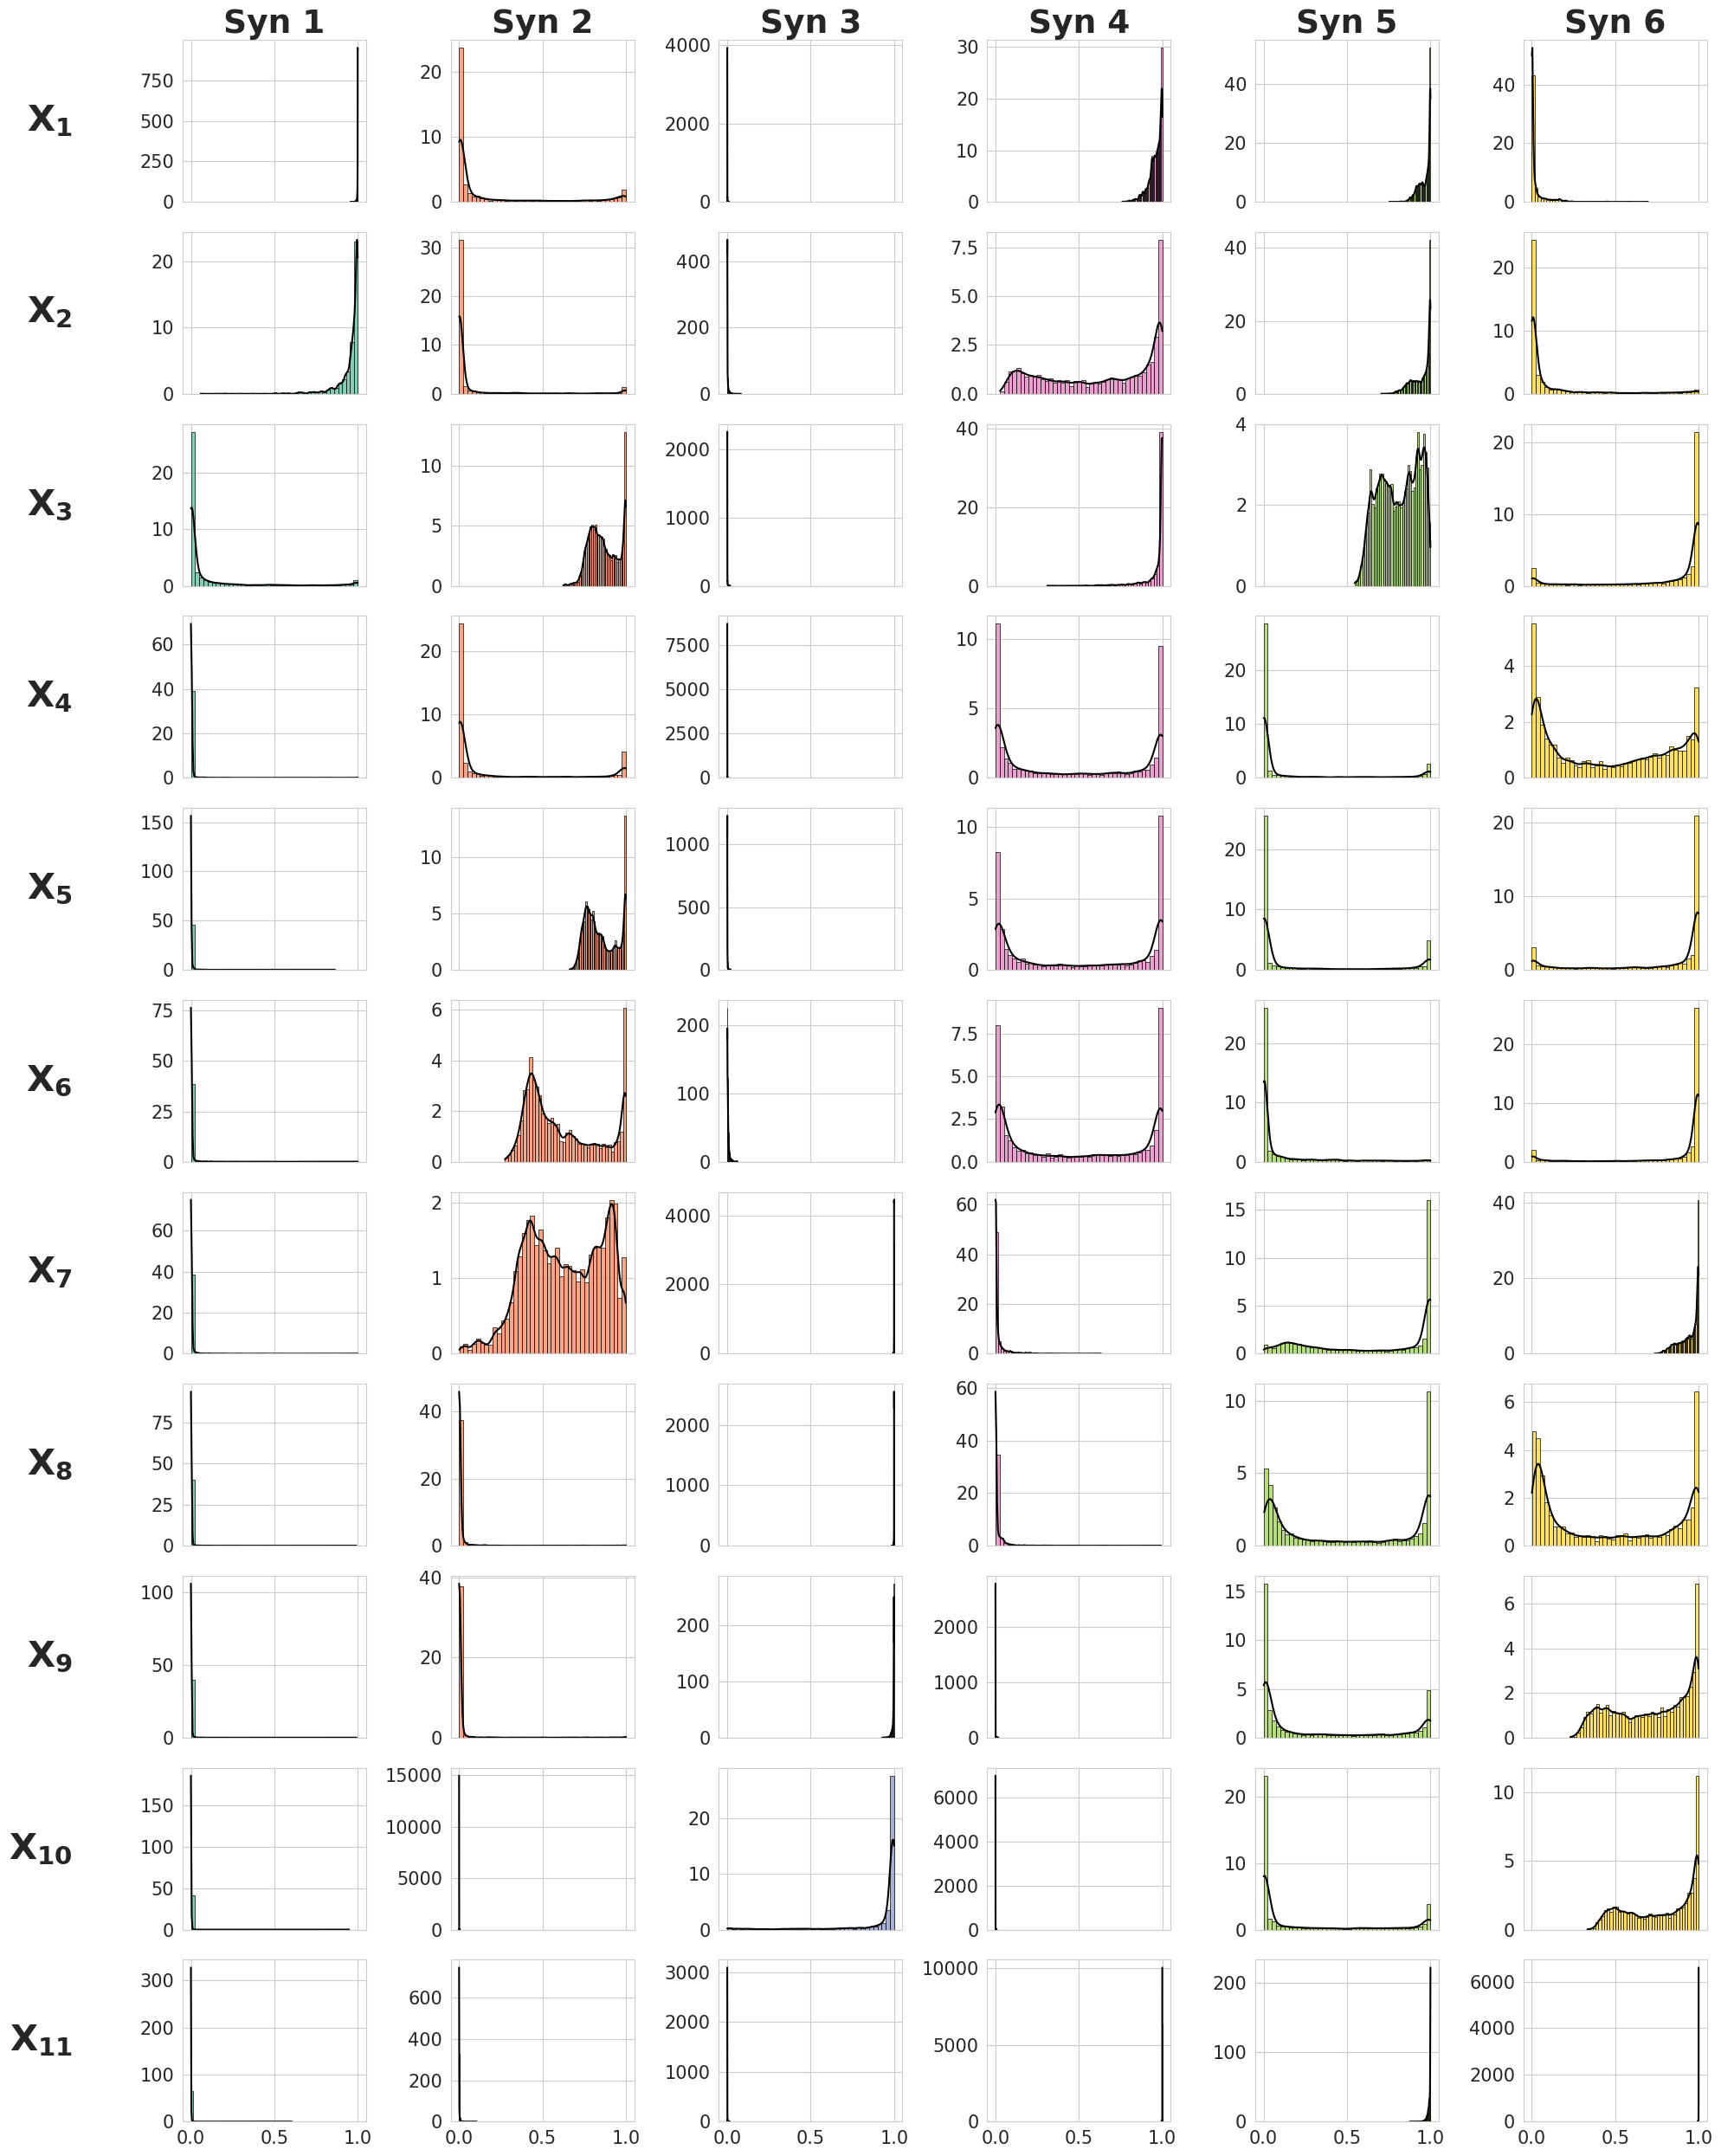

In [110]:
plot_mask_distributions(ploty_df, n_features=11)

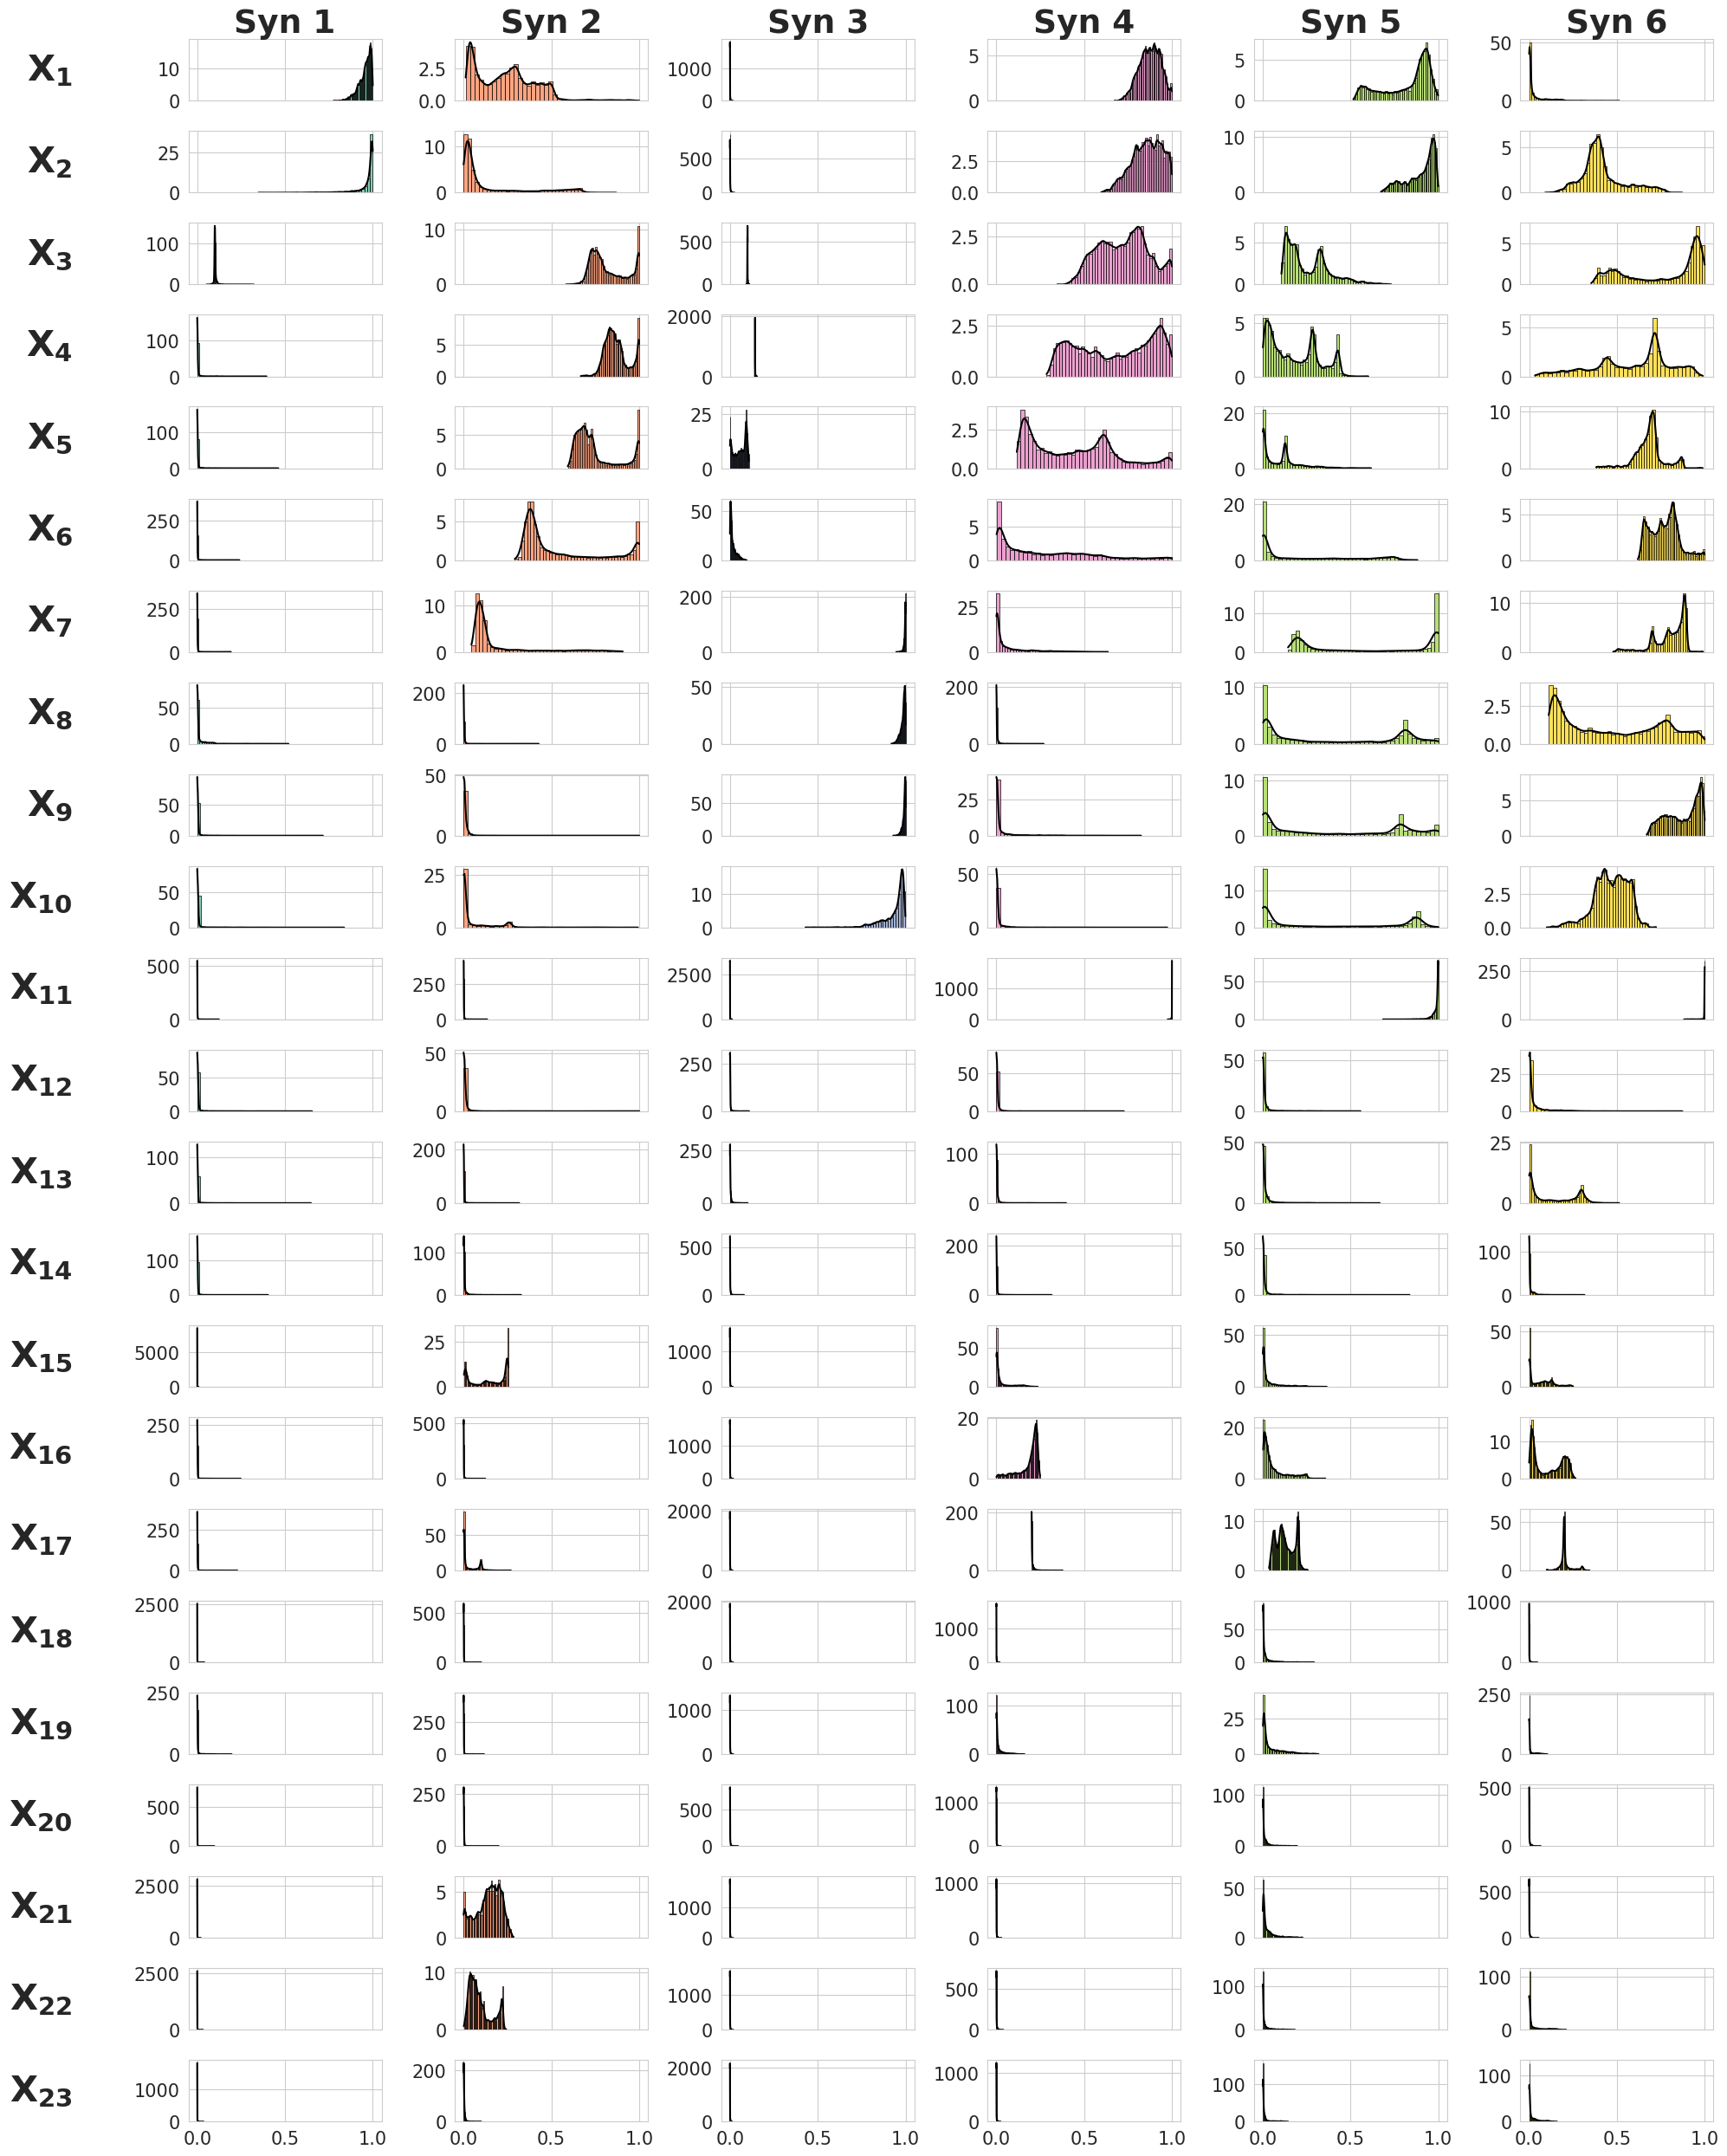

In [112]:
plot_mask_distributions(ploty_df_ens, n_features=None)

# True y

## Tuning lambda for true y

In [82]:
results = load_results_from_pickle(folder='ICML_experiments/semi_syn_cred/tuning_lambda_true_y',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                   is_synthetic=False#'bigtestuse_marginal_True'
                                        )#'after_hadi_conversation3')# #"%y_%m_%d_%H_%M_%S"

In [83]:
numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig']
for col in numeric_cols:
    temp[col] = temp[col].astype(float)

In [84]:
runs = temp.T.loc['run_id'].value_counts().index

In [85]:
coly = ['model', 'lmbda']

In [86]:
temp.loc[(temp['model']=="REAL-x") & (temp['seed'] == 1),'model']='REAL-x-2'

In [87]:
temp[coly].value_counts()

model      lmbda
Hide&Seek  0.01     1
           0.05     1
           0.10     1
           0.20     1
           0.30     1
           0.40     1
INVASE     0.01     1
           0.05     1
           0.10     1
           0.20     1
           0.30     1
           0.40     1
REAL-x     0.01     1
           0.05     1
           0.10     1
           0.20     1
           0.30     1
           0.40     1
dtype: int64

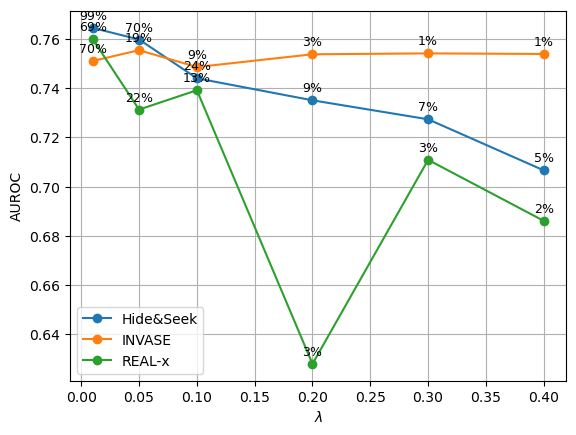

In [88]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

for model, g in temp[['model','lmbda','roc_auc','pct_sig']].groupby('model'):
    g = g.sort_values('lmbda')
    ax.plot(g['lmbda'], g['roc_auc'], marker='o', label=model)

    # annotate each point
    for _, row in g.iterrows():
        ax.annotate(
            f"{row['pct_sig']*100:.0f}%",
            (row['lmbda'], row['roc_auc']),
            textcoords="offset points",
            xytext=(0, 6),
            ha='center',
            fontsize=9
        )

ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('AUROC')
ax.legend()
ax.grid(True)
plt.show()


In [89]:
temp[['model','lmbda','roc_auc','pct_sig']].sort_values(by=['model','lmbda'])

,model,lmbda,roc_auc,pct_sig
0,Hide&Seek,0.01,0.764461,0.990522
1,Hide&Seek,0.05,0.759752,0.703667
2,Hide&Seek,0.10,0.744005,0.237087
3,Hide&Seek,0.20,0.735061,0.094739
4,Hide&Seek,0.30,0.727347,0.073261
5,Hide&Seek,0.40,0.706608,0.049957
12,INVASE,0.01,0.751056,0.703841
13,INVASE,0.05,0.755412,0.189188
14,INVASE,0.10,0.748576,0.088188
15,INVASE,0.20,0.753757,0.033594


Pick the lambda which has a high roc_auc for a low pct_sig. Before roc_auc drops off

- Hide&Seek: would like 0.05. But to compare prediction ability, should give similar number of features. Therefore: 0.1, 24%
- RealX: - hard choice between 0.05 and 0.1. In end match percentage of others. Choose 0.05, 22% (note this gave better results)
- INVASE: 0.05, 19%

## predictive performance - true y

In [96]:
results = load_results_from_pickle(folder='ICML_experiments/semi_syn_cred/after_tuning_lambda_true_y',
                                        time_threshold='25_09_03_12_00_00',
                                        keep_run_type=None,
                                          is_output=False,
                                   is_synthetic=False
                                        )

In [97]:
temp = results.copy()

In [13]:
# Rename the remaining models
rename_dict = {
    'hide_and_seek': 'Hide&Seek',
    'l2x': 'L2X',
    'lime': 'LIME',
    'invase': 'INVASE',
    'shap_xgboost':'SHAP',
    'lasso':"LASSO",
    'random_forest':"RForest"
}

temp = results.copy()#.drop(['run_type','time_run'])
temp = temp.T
temp['run_id'] = temp.apply(lambda x: str(x['time_run']) + '_' + str(x['run_type']),axis=1)
# temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)
temp['model'] = temp['model_type']
temp['model'] = temp['model'].replace(rename_dict)
temp['seed'] = temp['seed'].astype(int)
temp['pct_sig'] = temp['binary_mask'].apply(lambda x: x.mean(axis=1).mean())

In [98]:
numeric_cols = ['lmbda','accuracy', 'roc_auc', 'pct_sig']
for col in numeric_cols:
    temp[col] = temp[col].astype(float)

In [99]:
runs = temp.T.loc['run_id'].value_counts().index

In [100]:
temp[['model','lmbda']].value_counts()

model      lmbda
Hide&Seek  0.10     20
INVASE     0.05     20
REAL-x     0.05     20
           0.10     20
dtype: int64

In [104]:
temp = temp[~((temp['model']=='REAL-x') & (temp['lmbda']==0.1))]

In [105]:
temp[['model','lmbda']].value_counts()

model      lmbda
Hide&Seek  0.10     20
INVASE     0.05     20
REAL-x     0.05     20
dtype: int64

In [106]:
cols = ['model','lmbda', 'accuracy', 'roc_auc', 'pct_sig']
independent_medians = temp[cols].groupby(['model','lmbda']).median()
independent_medians

,,accuracy,roc_auc,pct_sig
model,lmbda,,,
Hide&Seek,0.10,0.829500,0.771706,0.200333
INVASE,0.05,0.822833,0.770946,0.227638
REAL-x,0.05,0.793500,0.757688,0.218420


In [107]:
metrics = ['roc_auc']
summary = (
    temp[cols]
    .groupby(['model', 'lmbda'])[metrics]
    .agg(['mean', 'sem'])   # sem = std / sqrt(n)
    .reset_index()
)
print(summary.round(3))

       model lmbda roc_auc       
                      mean    sem
0  Hide&Seek  0.10   0.770  0.002
1     INVASE  0.05   0.771  0.001
2     REAL-x  0.05   0.756  0.002
